In [1]:
import zipfile
import os

zip_path = "/content/ml-1m.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print(os.listdir("/content"))

['.config', 'ml-1m.zip', 'ml-1m', 'sample_data']


In [2]:
print(os.listdir("/content/ml-1m"))

['users.dat', 'README', 'ratings.dat', 'movies.dat']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
ratings = pd.read_csv(
    "/content/ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=[
        "UserID",
        "MovieID",
        "Rating",
        "Timestamp"
    ]
)

ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
ratings.shape

(1000209, 4)

In [6]:
movies = pd.read_csv(
    "/content/ml-1m/movies.dat",
    sep="::",
    engine="python",
    names=[
        "MovieID",
        "Title",
        "Genres"
    ],
    encoding="latin-1"
)

movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
movies.shape

(3883, 3)

In [8]:
users = pd.read_csv(
    "/content/ml-1m/users.dat",
    sep="::",
    engine="python",
    names=[
        "UserID",
        "Gender",
        "Age",
        "Occupation",
        "ZipCode"
    ]
)

users.head()

,UserID,Gender,Age,Occupation,ZipCode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [9]:
users.shape

(6040, 5)

In [10]:
print("Ratings:", ratings.shape)
print("Movies :", movies.shape)
print("Users  :", users.shape)

Ratings: (1000209, 4)
Movies : (3883, 3)
Users  : (6040, 5)


In [11]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [12]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   MovieID  3883 non-null   int64 
 1   Title    3883 non-null   object
 2   Genres   3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [13]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 2   Age         6040 non-null   int64 
 3   Occupation  6040 non-null   int64 
 4   ZipCode     6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


In [14]:
print("Ratings missing:")
print(ratings.isnull().sum())

print("\nMovies missing:")
print(movies.isnull().sum())

print("\nUsers missing:")
print(users.isnull().sum())

Ratings missing:
UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

Movies missing:
MovieID    0
Title      0
Genres     0
dtype: int64

Users missing:
UserID        0
Gender        0
Age           0
Occupation    0
ZipCode       0
dtype: int64


In [15]:
print(
    "Duplicate ratings:",
    ratings.duplicated().sum()
)

Duplicate ratings: 0


In [16]:
print(
    "Duplicate User-Movie pairs:",
    ratings.duplicated(
        subset=["UserID", "MovieID"]
    ).sum()
)

Duplicate User-Movie pairs: 0


In [17]:
rating_count = (
    ratings["Rating"]
    .value_counts()
    .sort_index()
)

rating_count

,count
Rating,
1,56174
2,107557
3,261197
4,348971
5,226310


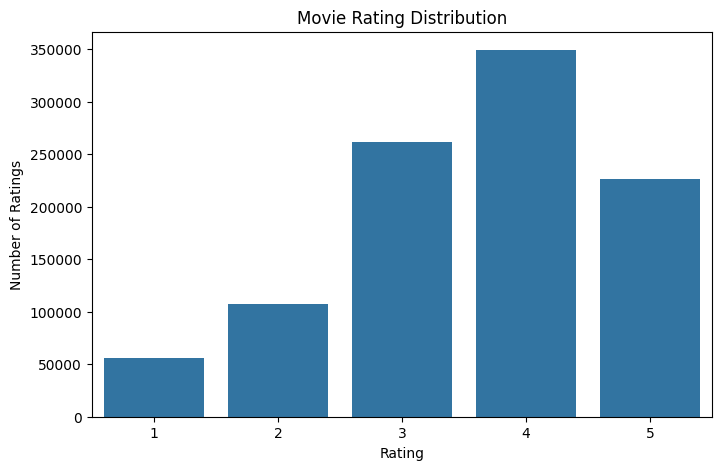

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=rating_count.index,
    y=rating_count.values
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

In [19]:
average_rating = ratings["Rating"].mean()

print(
    f"Average Rating: {average_rating:.2f}"
)

Average Rating: 3.58


In [21]:
movie_rating_stats = (
    ratings
    .groupby("MovieID")
    .agg(
        rating_count=("Rating", "count"),
        average_rating=("Rating", "mean")
    )
    .reset_index()
)

movie_rating_stats = movie_rating_stats.merge(
    movies,
    on="MovieID",
    how="left"
)

In [22]:
most_rated_movies = (
    movie_rating_stats
    .sort_values(
        "rating_count",
        ascending=False
    )
    .head(10)
)

most_rated_movies[
    [
        "Title",
        "rating_count",
        "average_rating"
    ]
]

,Title,rating_count,average_rating
2651,American Beauty (1999),3428,4.317386
253,Star Wars: Episode IV - A New Hope (1977),2991,4.453694
1106,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977
1120,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893
466,Jurassic Park (1993),2672,3.763847
1848,Saving Private Ryan (1998),2653,4.337354
575,Terminator 2: Judgment Day (1991),2649,4.058513
2374,"Matrix, The (1999)",2590,4.315830
1178,Back to the Future (1985),2583,3.990321
579,"Silence of the Lambs, The (1991)",2578,4.351823


In [23]:
high_rated_movies = (
    movie_rating_stats[
        movie_rating_stats["rating_count"] >= 100
    ]
    .sort_values(
        "average_rating",
        ascending=False
    )
    .head(10)
)

high_rated_movies[
    [
        "Title",
        "rating_count",
        "average_rating"
    ]
]

,Title,rating_count,average_rating
1839,Seven Samurai (The Magnificent Seven) (Shichin...,628,4.560510
309,"Shawshank Redemption, The (1994)",2227,4.554558
802,"Godfather, The (1972)",2223,4.524966
708,"Close Shave, A (1995)",657,4.520548
49,"Usual Suspects, The (1995)",1783,4.517106
513,Schindler's List (1993),2304,4.510417
1066,"Wrong Trousers, The (1993)",882,4.507937
861,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),470,4.491489
1108,Raiders of the Lost Ark (1981),2514,4.477725
843,Rear Window (1954),1050,4.476190


In [24]:
genre_df = movies[
    ["MovieID", "Genres"]
].copy()

genre_df["Genres"] = (
    genre_df["Genres"]
    .str.split("|")
)

genre_df = genre_df.explode(
    "Genres"
)

genre_df.head()

,MovieID,Genres
0,1,Animation
0,1,Children's
0,1,Comedy
1,2,Adventure
1,2,Children's


In [25]:
genre_rating = genre_df.merge(
    ratings[
        ["MovieID", "Rating"]
    ],
    on="MovieID",
    how="inner"
)

In [26]:
genre_stats = (
    genre_rating
    .groupby("Genres")
    .agg(
        rating_count=("Rating", "count"),
        average_rating=("Rating", "mean")
    )
    .sort_values(
        "average_rating",
        ascending=False
    )
)

genre_stats.head(10)

,rating_count,average_rating
Genres,,
Film-Noir,18261,4.075188
Documentary,7910,3.933123
War,68527,3.893327
Drama,354529,3.766332
Crime,79541,3.708679
Animation,43293,3.684868
Mystery,40178,3.668102
Musical,41533,3.665519
Western,20683,3.637770


In [27]:
user_activity = (
    ratings
    .groupby("UserID")
    .size()
    .sort_values(ascending=False)
)

user_activity.describe()

,0
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
25%,44.000000
50%,96.000000
75%,208.000000
max,2314.000000


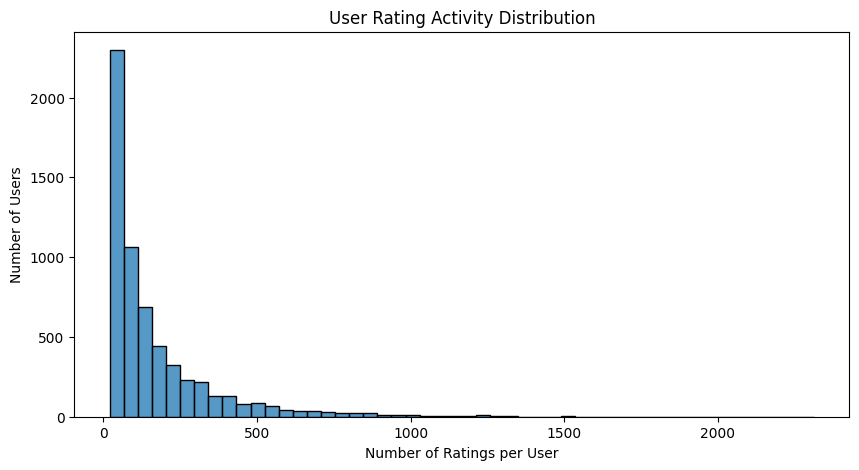

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    user_activity,
    bins=50
)

plt.title("User Rating Activity Distribution")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")

plt.show()

In [29]:
movie_popularity = (
    ratings
    .groupby("MovieID")
    .size()
    .sort_values(
        ascending=False
    )
)

movie_popularity.describe()

,0
count,3706.000000
mean,269.889099
std,384.047838
min,1.000000
25%,33.000000
50%,123.500000
75%,350.000000
max,3428.000000


In [30]:
user_item_matrix = ratings.pivot_table(
    index="UserID",
    columns="MovieID",
    values="Rating"
)

In [31]:
user_item_matrix.shape

(6040, 3706)

In [32]:
total_cells = (
    user_item_matrix.shape[0] *
    user_item_matrix.shape[1]
)

observed_cells = (
    user_item_matrix.count().sum()
)

sparsity = (
    1 -
    observed_cells / total_cells
) * 100

print(
    f"Sparsity: {sparsity:.2f}%"
)

Sparsity: 95.53%


In [33]:
user_item_filled = (
    user_item_matrix
    .fillna(0)
)

In [34]:
user_similarity = cosine_similarity(
    user_item_filled
)

In [35]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

user_similarity_df.iloc[:5, :5]

UserID,1,2,3,4,5
UserID,,,,,
1,1.000000,0.096382,0.120610,0.132455,0.090158
2,0.096382,1.000000,0.151479,0.171176,0.114394
3,0.120610,0.151479,1.000000,0.151227,0.062907
4,0.132455,0.171176,0.151227,1.000000,0.045094
5,0.090158,0.114394,0.062907,0.045094,1.000000


In [36]:
target_user = 1

In [37]:
similar_users = (
    user_similarity_df[target_user]
    .sort_values(
        ascending=False
    )
)

similar_users.head(10)

,1
UserID,
1,1.000000
5343,0.412117
5190,0.411899
1481,0.392110
1283,0.386597
5705,0.360898
5762,0.355600
1359,0.350329
1476,0.339496


In [38]:
similar_users = similar_users.drop(
    target_user
)

similar_users.head(10)

,1
UserID,
5343,0.412117
5190,0.411899
1481,0.392110
1283,0.386597
5705,0.360898
5762,0.355600
1359,0.350329
1476,0.339496
541,0.334864


In [39]:
def recommend_movies(
    user_id,
    similarity_df,
    user_item_df,
    movies_df,
    top_n=10,
    similar_n=20
):
    similar_users = (
        similarity_df[user_id]
        .drop(user_id)
        .sort_values(
            ascending=False
        )
        .head(similar_n)
    )

    target_rated = set(
        user_item_df.loc[
            user_id
        ]
        .dropna()
        .index
    )

    candidate_scores = {}

    for similar_user, similarity_score in similar_users.items():

        user_ratings = (
            user_item_df
            .loc[similar_user]
            .dropna()
        )

        for movie_id, rating in user_ratings.items():

            if movie_id in target_rated:
                continue

            if movie_id not in candidate_scores:
                candidate_scores[movie_id] = 0

            candidate_scores[movie_id] += (
                similarity_score * rating
            )

    recommendations = (
        pd.Series(candidate_scores)
        .sort_values(
            ascending=False
        )
        .head(top_n)
        .reset_index()
    )

    recommendations.columns = [
        "MovieID",
        "Score"
    ]

    recommendations = recommendations.merge(
        movies_df,
        on="MovieID",
        how="left"
    )

    return recommendations

In [40]:
recommend_movies(
    user_id=1,
    similarity_df=user_similarity_df,
    user_item_df=user_item_matrix,
    movies_df=movies,
    top_n=10
)

,MovieID,Score,Title,Genres
0,2081,26.871580,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance
1,2078,21.505417,"Jungle Book, The (1967)",Animation|Children's|Comedy|Musical
2,2096,21.331298,Sleeping Beauty (1959),Animation|Children's|Musical
3,364,20.452152,"Lion King, The (1994)",Animation|Children's|Musical
4,1282,19.933136,Fantasia (1940),Animation|Children's|Musical
5,2085,17.117685,101 Dalmatians (1961),Animation|Children's
6,2087,17.060706,Peter Pan (1953),Animation|Children's|Fantasy|Musical
7,1210,16.708613,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War
8,480,16.574196,Jurassic Park (1993),Action|Adventure|Sci-Fi
9,2080,16.467332,Lady and the Tramp (1955),Animation|Children's|Comedy|Musical|Romance


In [42]:
popularity_baseline = (
    movie_rating_stats[
        movie_rating_stats["rating_count"] >= 100
    ]
    .sort_values(
        ["rating_count", "average_rating"],
        ascending=False
    )
    .head(10)
)

popularity_baseline[
    [
        "MovieID",
        "Title",
        "rating_count",
        "average_rating"
    ]
]

,MovieID,Title,rating_count,average_rating
2651,2858,American Beauty (1999),3428,4.317386
253,260,Star Wars: Episode IV - A New Hope (1977),2991,4.453694
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893
466,480,Jurassic Park (1993),2672,3.763847
1848,2028,Saving Private Ryan (1998),2653,4.337354
575,589,Terminator 2: Judgment Day (1991),2649,4.058513
2374,2571,"Matrix, The (1999)",2590,4.315830
1178,1270,Back to the Future (1985),2583,3.990321
579,593,"Silence of the Lambs, The (1991)",2578,4.351823


In [43]:
ratings_sorted = ratings.sort_values(
    ["UserID", "Timestamp"]
).copy()

In [44]:
test_ratings = (
    ratings_sorted
    .groupby("UserID")
    .tail(1)
    .copy()
)

In [45]:
train_ratings = ratings_sorted.drop(
    test_ratings.index
)

In [46]:
print("Train:", train_ratings.shape)
print("Test :", test_ratings.shape)
print("Users in test:", test_ratings["UserID"].nunique())

Train: (994169, 4)
Test : (6040, 4)
Users in test: 6040


In [47]:
train_matrix = train_ratings.pivot_table(
    index="UserID",
    columns="MovieID",
    values="Rating"
)

In [48]:
train_matrix_filled = (
    train_matrix.fillna(0)
)

In [49]:
train_user_similarity = cosine_similarity(
    train_matrix_filled
)

In [50]:
train_similarity_df = pd.DataFrame(
    train_user_similarity,
    index=train_matrix_filled.index,
    columns=train_matrix_filled.index
)

In [51]:
recommend_movies(
    user_id=1,
    similarity_df=train_similarity_df,
    user_item_df=train_matrix,
    movies_df=movies,
    top_n=10
)

,MovieID,Score,Title,Genres
0,2081,25.309323,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance
1,2078,23.130753,"Jungle Book, The (1967)",Animation|Children's|Comedy|Musical
2,364,21.047723,"Lion King, The (1994)",Animation|Children's|Musical
3,1282,20.015433,Fantasia (1940),Animation|Children's|Musical
4,2096,17.873461,Sleeping Beauty (1959),Animation|Children's|Musical
5,593,17.582203,"Silence of the Lambs, The (1991)",Drama|Thriller
6,1196,17.541069,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War
7,2087,17.399372,Peter Pan (1953),Animation|Children's|Fantasy|Musical
8,1265,17.282578,Groundhog Day (1993),Comedy|Romance
9,1198,16.891656,Raiders of the Lost Ark (1981),Action|Adventure


In [52]:
test_positive = test_ratings[
    test_ratings["Rating"] >= 4
].copy()

In [53]:
print(
    "Positive test ratings:",
    len(test_positive)
)

Positive test ratings: 3563


In [54]:
def precision_at_k(
    recommended_movies,
    relevant_movies,
    k=10
):
    recommended = set(
        recommended_movies[:k]
    )

    relevant = set(
        relevant_movies
    )

    if len(recommended) == 0:
        return 0

    return len(
        recommended & relevant
    ) / len(recommended)

In [55]:
def recall_at_k(
    recommended_movies,
    relevant_movies,
    k=10
):
    recommended = set(
        recommended_movies[:k]
    )

    relevant = set(
        relevant_movies
    )

    if len(relevant) == 0:
        return 0

    return len(
        recommended & relevant
    ) / len(relevant)

In [56]:
precision_scores = []
recall_scores = []

for user_id in test_positive["UserID"].unique():

    if user_id not in train_matrix.index:
        continue

    recommendations = recommend_movies(
        user_id=user_id,
        similarity_df=train_similarity_df,
        user_item_df=train_matrix,
        movies_df=movies,
        top_n=10
    )

    if recommendations.empty:
        continue

    recommended_ids = (
        recommendations["MovieID"]
        .tolist()
    )

    relevant_ids = (
        test_positive[
            test_positive["UserID"] == user_id
        ]["MovieID"]
        .tolist()
    )

    precision_scores.append(
        precision_at_k(
            recommended_ids,
            relevant_ids,
            k=10
        )
    )

    recall_scores.append(
        recall_at_k(
            recommended_ids,
            relevant_ids,
            k=10
        )
    )

In [57]:
mean_precision = np.mean(
    precision_scores
)

mean_recall = np.mean(
    recall_scores
)

print(
    f"Mean Precision@10: "
    f"{mean_precision:.4f}"
)

print(
    f"Mean Recall@10: "
    f"{mean_recall:.4f}"
)

Mean Precision@10: 0.0109
Mean Recall@10: 0.1095


In [58]:
popular_movies = (
    popularity_baseline["MovieID"]
    .tolist()
)

In [59]:
pop_precision_scores = []
pop_recall_scores = []

for user_id in test_positive["UserID"].unique():

    relevant_ids = (
        test_positive[
            test_positive["UserID"] == user_id
        ]["MovieID"]
        .tolist()
    )

    pop_precision_scores.append(
        precision_at_k(
            popular_movies,
            relevant_ids,
            k=10
        )
    )

    pop_recall_scores.append(
        recall_at_k(
            popular_movies,
            relevant_ids,
            k=10
        )
    )

In [60]:
pop_mean_precision = np.mean(
    pop_precision_scores
)

pop_mean_recall = np.mean(
    pop_recall_scores
)

print(
    f"Popularity Precision@10: "
    f"{pop_mean_precision:.4f}"
)

print(
    f"Popularity Recall@10: "
    f"{pop_mean_recall:.4f}"
)

Popularity Precision@10: 0.0022
Popularity Recall@10: 0.0222


In [61]:
recommendation_comparison = pd.DataFrame({
    "Model": [
        "Popularity Baseline",
        "User-Based Collaborative Filtering"
    ],
    "Precision@10": [
        pop_mean_precision,
        mean_precision
    ],
    "Recall@10": [
        pop_mean_recall,
        mean_recall
    ]
})

recommendation_comparison

,Model,Precision@10,Recall@10
0,Popularity Baseline,0.002217,0.022172
1,User-Based Collaborative Filtering,0.010946,0.109458


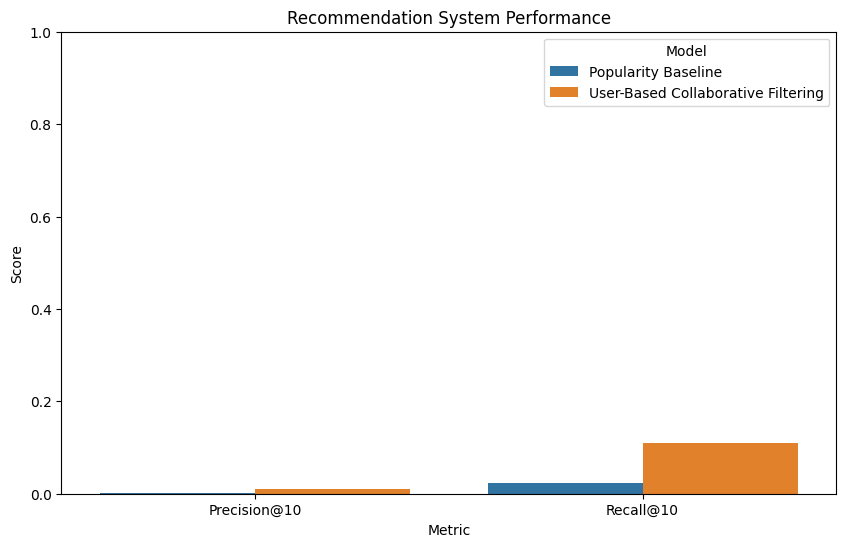

In [62]:
comparison_long = (
    recommendation_comparison
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)

plt.title(
    "Recommendation System Performance"
)

plt.ylabel("Score")

plt.show()

In [63]:
item_user_matrix = train_ratings.pivot_table(
    index="MovieID",
    columns="UserID",
    values="Rating"
)

In [64]:
item_user_filled = (
    item_user_matrix.fillna(0)
)

In [65]:
item_similarity = cosine_similarity(
    item_user_filled
)

In [66]:
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_filled.index,
    columns=item_user_filled.index
)

In [67]:
item_similarity_df.iloc[:5, :5]

MovieID,1,2,3,4,5
MovieID,,,,,
1,1.000000,0.390704,0.269217,0.178849,0.257606
2,0.390704,1.000000,0.242150,0.155546,0.251040
3,0.269217,0.242150,1.000000,0.193640,0.310799
4,0.178849,0.155546,0.193640,1.000000,0.271061
5,0.257606,0.251040,0.310799,0.271061,1.000000


In [68]:
def recommend_movies_item_based(
    user_id,
    item_similarity_df,
    user_item_df,
    movies_df,
    top_n=10,
    similar_n=20
):
    user_ratings = (
        user_item_df
        .loc[user_id]
        .dropna()
        .sort_values(ascending=False)
    )

    rated_movies = set(
        user_ratings.index
    )

    candidate_scores = {}

    top_rated_movies = (
        user_ratings
        .head(similar_n)
    )

    for movie_id, rating in top_rated_movies.items():

        if movie_id not in item_similarity_df.index:
            continue

        similar_items = (
            item_similarity_df[movie_id]
            .drop(movie_id, errors="ignore")
            .sort_values(
                ascending=False
            )
            .head(similar_n)
        )

        for similar_movie, similarity_score in similar_items.items():

            if similar_movie in rated_movies:
                continue

            if similar_movie not in candidate_scores:
                candidate_scores[similar_movie] = 0

            candidate_scores[similar_movie] += (
                similarity_score * rating
            )

    recommendations = (
        pd.Series(candidate_scores)
        .sort_values(
            ascending=False
        )
        .head(top_n)
        .reset_index()
    )

    recommendations.columns = [
        "MovieID",
        "Score"
    ]

    recommendations = recommendations.merge(
        movies_df,
        on="MovieID",
        how="left"
    )

    return recommendations

In [69]:
recommend_movies_item_based(
    user_id=1,
    item_similarity_df=item_similarity_df,
    user_item_df=train_matrix,
    movies_df=movies,
    top_n=10
)

,MovieID,Score,Title,Genres
0,1196,22.319149,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War
1,364,21.771437,"Lion King, The (1994)",Animation|Children's|Musical
2,318,21.093600,"Shawshank Redemption, The (1994)",Drama
3,1198,21.060325,Raiders of the Lost Ark (1981),Action|Adventure
4,1265,19.810458,Groundhog Day (1993),Comedy|Romance
5,2096,17.050483,Sleeping Beauty (1959),Animation|Children's|Musical
6,2081,16.456184,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance
7,2080,15.497513,Lady and the Tramp (1955),Animation|Children's|Comedy|Musical|Romance
8,1580,15.370670,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi
9,2078,14.984571,"Jungle Book, The (1967)",Animation|Children's|Comedy|Musical


In [70]:
item_precision_scores = []
item_recall_scores = []

for user_id in test_positive["UserID"].unique():

    if user_id not in train_matrix.index:
        continue

    recommendations = recommend_movies_item_based(
        user_id=user_id,
        item_similarity_df=item_similarity_df,
        user_item_df=train_matrix,
        movies_df=movies,
        top_n=10
    )

    if recommendations.empty:
        continue

    recommended_ids = (
        recommendations["MovieID"]
        .tolist()
    )

    relevant_ids = (
        test_positive[
            test_positive["UserID"] == user_id
        ]["MovieID"]
        .tolist()
    )

    item_precision_scores.append(
        precision_at_k(
            recommended_ids,
            relevant_ids,
            k=10
        )
    )

    item_recall_scores.append(
        recall_at_k(
            recommended_ids,
            relevant_ids,
            k=10
        )
    )

In [71]:
item_mean_precision = np.mean(
    item_precision_scores
)

item_mean_recall = np.mean(
    item_recall_scores
)

print(
    f"Item-Based Precision@10: "
    f"{item_mean_precision:.4f}"
)

print(
    f"Item-Based Recall@10: "
    f"{item_mean_recall:.4f}"
)

Item-Based Precision@10: 0.0097
Item-Based Recall@10: 0.0974


In [72]:
recommendation_comparison_final = pd.DataFrame({
    "Model": [
        "Popularity Baseline",
        "User-Based Collaborative Filtering",
        "Item-Based Collaborative Filtering"
    ],
    "Precision@10": [
        pop_mean_precision,
        mean_precision,
        item_mean_precision
    ],
    "Recall@10": [
        pop_mean_recall,
        mean_recall,
        item_mean_recall
    ]
})

recommendation_comparison_final

,Model,Precision@10,Recall@10
0,Popularity Baseline,0.002217,0.022172
1,User-Based Collaborative Filtering,0.010946,0.109458
2,Item-Based Collaborative Filtering,0.009739,0.097390


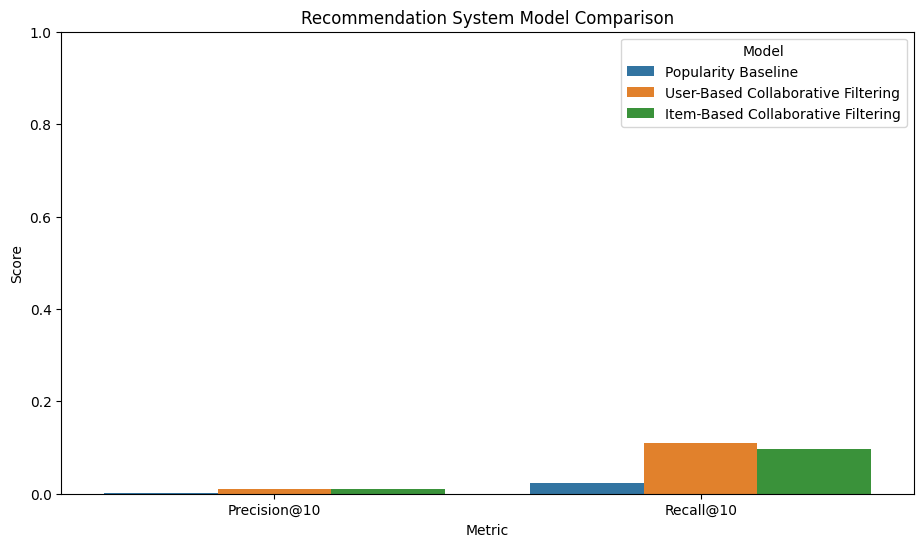

In [73]:
comparison_long = (
    recommendation_comparison_final
    .melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)

plt.title(
    "Recommendation System Model Comparison"
)

plt.ylabel("Score")

plt.show()

## Key Findings

### 1. The dataset contains a large number of user-item interactions

The MovieLens dataset contains:

- 1,000,209 ratings
- 6,040 users
- 3,883 movies

The user-item matrix contains 6,040 users and 3,706 movies with observed ratings.

### 2. The rating distribution is concentrated around positive ratings

The average rating across the dataset is approximately 3.58 out of 5.

Higher ratings occur more frequently than low ratings, indicating that users tend to provide relatively positive evaluations.

### 3. The recommendation matrix is highly sparse

The user-item matrix has approximately 95.53% sparsity.

This means that each user has interacted with only a small portion of the available movies, making collaborative filtering useful for discovering relationships between users and movies.

### 4. Collaborative Filtering outperformed the popularity baseline

The popularity baseline achieved:

- Precision@10: 0.002217
- Recall@10: 0.022172

User-Based Collaborative Filtering achieved:

- Precision@10: 0.010946
- Recall@10: 0.109458

This represents approximately a 4.94× improvement in both evaluation metrics.

### 5. User-Based Collaborative Filtering slightly outperformed Item-Based Collaborative Filtering

The two collaborative filtering approaches achieved:

| Model | Precision@10 | Recall@10 |
|---|---:|---:|
| User-Based Collaborative Filtering | **0.010946** | **0.109458** |
| Item-Based Collaborative Filtering | 0.009739 | 0.097390 |

User-Based Collaborative Filtering therefore became the final recommendation approach for this project.

### 6. Personalized recommendations outperform generic popularity recommendations

The improvement over the popularity baseline indicates that using user similarity can provide more personalized recommendations than simply recommending the most frequently rated movies.

## Business Insight

A recommendation system can help digital entertainment platforms personalize content discovery.

Potential applications include:

- Personalized movie recommendations
- Increasing content discovery
- Improving user engagement
- Supporting homepage personalization
- Reducing the effort required to find relevant content
- Improving long-term user retention

Instead of presenting identical popular movies to every user, collaborative filtering can use historical user behavior to generate more personalized recommendations.

For example, users with similar rating behavior can be used to identify movies that one user has not yet rated but may be interested in.

## Conclusion

This project developed a movie recommendation system using collaborative filtering on the MovieLens 1M dataset.

The analysis covered data understanding, rating analysis, movie popularity analysis, user-item matrix construction, user-based collaborative filtering, item-based collaborative filtering, and Top-N recommendation evaluation.

Three recommendation strategies were compared:

1. Popularity Baseline
2. User-Based Collaborative Filtering
3. Item-Based Collaborative Filtering

User-Based Collaborative Filtering achieved the best performance with:

- Precision@10: **0.010946**
- Recall@10: **0.109458**

Compared with the popularity baseline, User-Based Collaborative Filtering improved both metrics by approximately 4.94×.

The results demonstrate that incorporating user similarity can produce more personalized recommendations than relying only on global movie popularity.

However, the recommendation system still operates under a highly sparse user-item matrix, with approximately 95.53% sparsity. Future improvements could include matrix factorization, implicit feedback, hybrid recommendation systems, or more advanced neural recommendation approaches.

Overall, the project demonstrates how collaborative filtering can transform historical user-item interactions into personalized content recommendations.